\begin{center}
{\LARGE \textbf{EN3160 Image Processing and Machine Vision}}\\[0.5em]
{\Large Assignment 1 -- Intensity Transformations and Neighborhood Filtering}\\[1.5em]

\textbf{Name:} S.A.D. Priyadarshana\\[0.3em]
\textbf{Index:} 230502X\\[0.3em]
\textbf{GitHub:} \href{https://github.com/denethp/CV-Assignment-01}{denethp/CV-Assignment-01}
\end{center}

\vspace{1em}

$\underline{\textbf{Question 1}}$

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
def intensity_transform(im, breakpoints):
    # Piecewise-linear LUT built from linspace segments placed by index;
    # a repeated x value (vertical jump) simply overwrites that index.
    bp = np.array(breakpoints, dtype=np.float64)
    t = np.zeros(256)

    for i in range(len(bp) - 1):
        x0, y0 = bp[i]
        x1, y1 = bp[i + 1]
        x0, x1 = int(x0), int(x1)
        if x1 == x0:
            t[x0] = y1
        else:
            t[x0:x1 + 1] = np.linspace(y0, y1, x1 - x0 + 1)

    t = t.astype('uint8')
    return cv.LUT(im, t), t

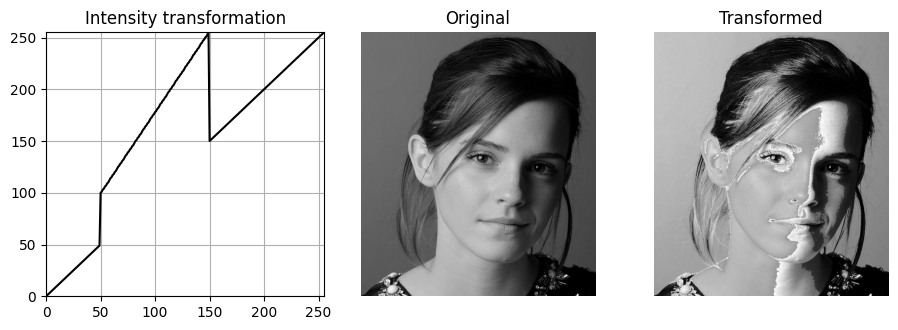

In [3]:
img = cv.imread('images/emma.jpg', cv.IMREAD_GRAYSCALE)

breakpoints = [[0, 0], [49, 49], [50, 100], [149, 255], [150, 150], [255, 255]]
transformed, lut = intensity_transform(img, breakpoints)

fig, axes = plt.subplots(1, 3, figsize=(9.3, 3.4))
axes[0].plot(np.arange(256), lut, color='k')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].set_title('Intensity transformation')
axes[0].grid(True)

axes[1].imshow(img, cmap='gray')
axes[1].set_title('Original')
axes[1].axis('off')

axes[2].imshow(transformed, cmap='gray')
axes[2].set_title('Transformed')
axes[2].axis('off')
plt.tight_layout()
plt.show()

$\textbf{Discussion:}$ these breakpoints reproduce the sawtooth curve shown in Fig. 1a: a near-vertical jump from 49 up to 100 at x = 49-50, a steady rise to 255 by x = 149, another near-vertical drop back down to 150 at x = 149-150, then a rise back to 255 by x = 255. Applying this LUT compresses the mid-to-high intensities into two overlapping output bands, which shows up as visible banding/posterization on the brighter parts of the face (forehead, cheek, eyebrow) where neighbouring pixels straddle the two discontinuities.

$\textbf{Experimenting with other breakpoints for a visually pleasing output}$

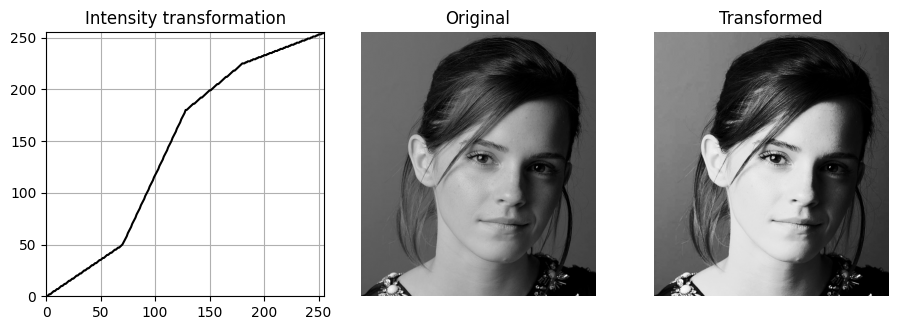

In [4]:
breakpoints2 = [[0, 0], [70, 50], [128, 180], [180, 225], [255, 255]]
transformed2, lut2 = intensity_transform(img, breakpoints2)

fig, axes = plt.subplots(1, 3, figsize=(9.3, 3.4))
axes[0].plot(np.arange(256), lut2, color='k')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].set_title('Intensity transformation')
axes[0].grid(True)

axes[1].imshow(img, cmap='gray')
axes[1].set_title('Original')
axes[1].axis('off')

axes[2].imshow(transformed2, cmap='gray')
axes[2].set_title('Transformed')
axes[2].axis('off')
plt.tight_layout()
plt.show()

$\textbf{Discussion:}$ several breakpoint sets were tried on the image (keeping the same overall rising S-curve shape as Fig. 1a but rounding off the near-vertical jumps into steep-but-continuous ramps) to find a visually pleasing result. The breakpoints (0,0), (70,50), (128,180), (180,225), (255,255) boost mid-tone contrast strongly, sharpening the separation between the face and the background, while the smooth ramps (instead of vertical jumps) avoid the banding/posterization seen in the literal Fig. 1a reproduction above, giving a natural-looking, higher-contrast result with no loss of detail in the shadows or highlights.

$\underline{\textbf{Question 2}}$

$\textbf{(a) Accentuating white matter}$

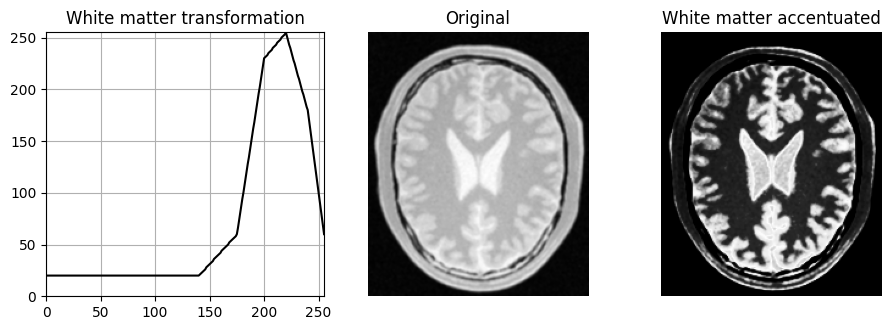

In [5]:
img2 = cv.imread('images/brain_proton_density.jpeg', cv.IMREAD_GRAYSCALE)
# Light blur suppresses JPEG blockiness before stretching
img2 = cv.GaussianBlur(img2, (3, 3), 0)

# White matter sits roughly in the 200-220 band
white_bp = [[0, 20], [140, 20], [175, 60], [200, 230],
            [220, 255], [240, 180], [255, 60]]
white_out, white_lut = intensity_transform(img2, white_bp)

fig, axes = plt.subplots(1, 3, figsize=(9.3, 3.4))
axes[0].plot(np.arange(256), white_lut, color='k')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].set_title('White matter transformation')
axes[0].grid(True)

axes[1].imshow(img2, cmap='gray')
axes[1].set_title('Original')
axes[1].axis('off')

axes[2].imshow(white_out, cmap='gray')
axes[2].set_title('White matter accentuated')
axes[2].axis('off')
plt.tight_layout()
plt.show()

$\textbf{(b) Accentuating gray matter}$

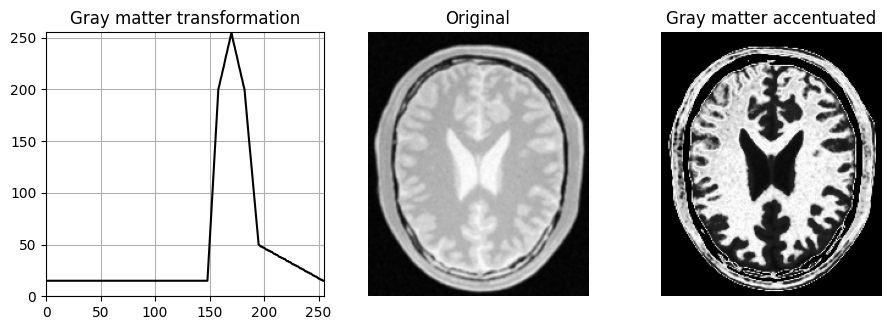

In [6]:
# Gray matter (cortex) sits in a lower band than white matter (~155-185)
gray_bp = [[0, 15], [148, 15], [158, 200], [170, 255],
           [182, 200], [195, 50], [255, 15]]
gray_out, gray_lut = intensity_transform(img2, gray_bp)

fig, axes = plt.subplots(1, 3, figsize=(9.3, 3.4))
axes[0].plot(np.arange(256), gray_lut, color='k')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].set_title('Gray matter transformation')
axes[0].grid(True)

axes[1].imshow(img2, cmap='gray')
axes[1].set_title('Original')
axes[1].axis('off')

axes[2].imshow(gray_out, cmap='gray')
axes[2].set_title('Gray matter accentuated')
axes[2].axis('off')
plt.tight_layout()
plt.show()

$\textbf{Discussion:}$ both transformations isolate a narrow intensity band and suppress everything else, but the white-matter curve targets the higher band (approx. 195-230, capturing the ventricles/CSF and deep white matter) while the gray-matter curve targets the lower band (approx. 155-185, capturing the folded cortical ribbon). This gives two clearly complementary results: the cortex is bright and the ventricles are dark in the gray-matter output, and the reverse is true in the white-matter output. Because the two tissue types have overlapping, JPEG-noisy intensity distributions in this image, neither result is perfectly clean, some skull pixels (which share intensities with brain tissue) leak through in both.

$\underline{\textbf{Question 3}}$

$\textbf{(a) Gamma correction on the L plane in $L^*a^*b^*$ space}$

$\gamma = 0.5$

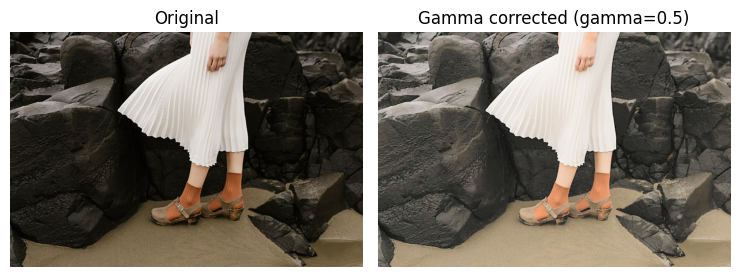

In [7]:
img3 = cv.imread('images/gamma_correction.jpeg')
lab = cv.cvtColor(img3, cv.COLOR_BGR2LAB)
L, a, b = cv.split(lab)

gamma = 0.5  # rocks are dark, gamma < 1 lifts the shadows
L_corrected = (255.0 * (L / 255.0) ** gamma).clip(0, 255).astype(np.uint8)

lab_corrected = cv.merge([L_corrected, a, b])
img3_corrected = cv.cvtColor(lab_corrected, cv.COLOR_LAB2BGR)

imgs = [(img3, 'Original'),
        (img3_corrected, f'Gamma corrected (gamma={gamma})')]
fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.7))
for ax, (im, title) in zip(axes, imgs):
    ax.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

$\textbf{(b) Histograms before and after correction}$

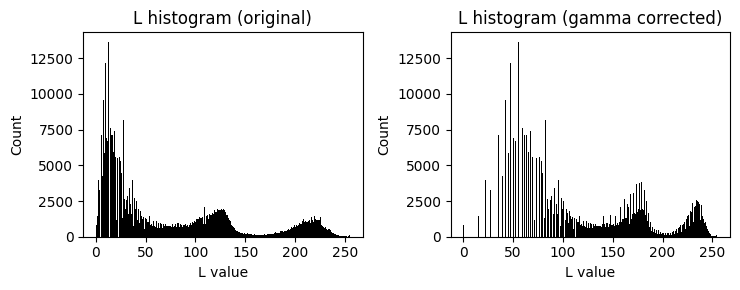

In [8]:
hists = [(L, 'L histogram (original)'),
         (L_corrected, 'L histogram (gamma corrected)')]
fig, axes = plt.subplots(1, 2, figsize=(7.5, 3))
for ax, (data, title) in zip(axes, hists):
    ax.hist(data.flatten(), bins=256, range=(0, 255), color='k')
    ax.set_title(title)
    ax.set_xlabel('L value')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

$\textbf{Discussion:}$ applying $\gamma = 0.5$ only to the L channel lifts the dark shadow regions without altering hue or saturation, avoiding the colour shift that gamma correction in RGB space would cause. The histogram confirms this: the corrected L histogram is shifted and stretched toward higher values while keeping roughly the same shape, since $\gamma < 1$ is a monotonic contrast remap rather than a channel-mixing operation.

$\underline{\textbf{Question 4}}$

$\textbf{(a) Split into hue, saturation, and value planes}$

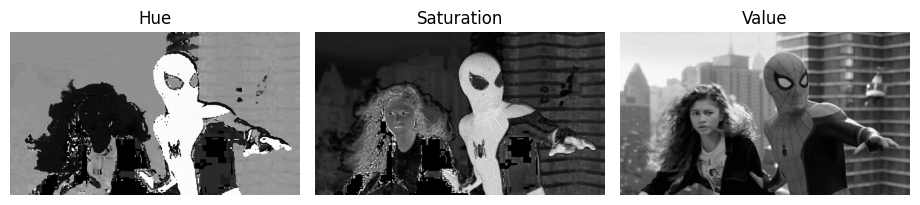

In [9]:
img4 = cv.imread('images/vibrance.jpeg')
hsv = cv.cvtColor(img4, cv.COLOR_BGR2HSV)
H, S, V = cv.split(hsv)

planes = [(H, 'Hue'), (S, 'Saturation'), (V, 'Value')]
fig, axes = plt.subplots(1, 3, figsize=(9.3, 3.4))
for ax, (im, title) in zip(axes, planes):
    ax.imshow(im, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

$\textbf{(b) Apply the vibrance transformation to the saturation plane}$

In [10]:
sigma = 70
a = 0.6  # largest boost that did not visibly oversaturate skin tones

x = np.arange(256).astype(np.float64)
bump = a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2))
vibrance_curve = np.minimum(x + bump, 255)
vibrance_lut = vibrance_curve.astype(np.uint8)

S_boosted = cv.LUT(S, vibrance_lut)

$\textbf{(c) Choosing the value for $a$}$
Chose $a = 0.6$ (it was the most visually pleasing value).

$\textbf{(d) Recombine the planes}$

In [11]:
hsv_boosted = cv.merge([H, S_boosted, V])
img4_boosted = cv.cvtColor(hsv_boosted, cv.COLOR_HSV2BGR)

$\textbf{(e) Original, vibrance-enhanced image, and the transformation}$

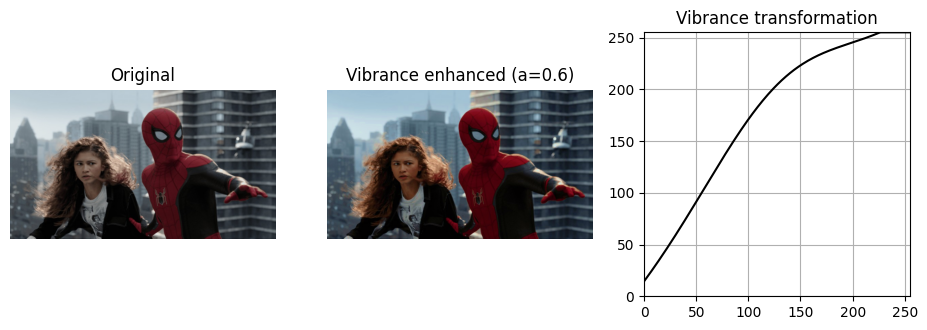

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(9.3, 3.4))
axes[0].imshow(cv.cvtColor(img4, cv.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(cv.cvtColor(img4_boosted, cv.COLOR_BGR2RGB))
axes[1].set_title(f'Vibrance enhanced (a={a})')
axes[1].axis('off')

axes[2].plot(x, vibrance_curve, color='k')
axes[2].set_xlim(0, 255)
axes[2].set_ylim(0, 255)
axes[2].set_title('Vibrance transformation')
axes[2].grid(True)
plt.tight_layout()
plt.show()

$\textbf{Discussion:}$ the Gaussian-bump curve leaves saturation near 0 and 255 almost unchanged while boosting mid-range saturation values, which is where most of the image's colour pixels sit. This produces a richer, more vivid image without clipping already-saturated colours or amplifying noise in the near-gray regions.

$\underline{\textbf{Question 5}}$

In [13]:
def histogram_equalization(im):
    # Equalize using the image's own CDF, mapped to 0-255
    hist = np.bincount(im.flatten(), minlength=256)
    cdf = np.cumsum(hist)
    cdf_min = cdf[cdf > 0].min()
    lut = (cdf - cdf_min) / (cdf[-1] - cdf_min) * 255
    lut = np.clip(lut, 0, 255).astype(np.uint8)
    return lut[im]

[ WARN:0@3.972] global grfmt_tiff.cpp:122 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null


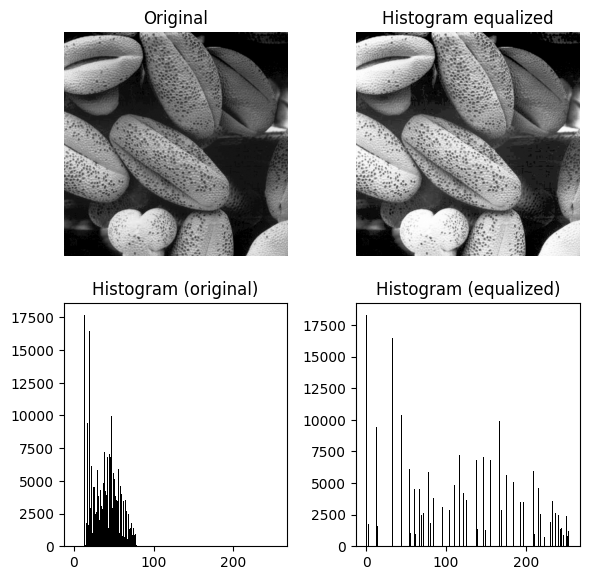

In [14]:
img5 = cv.imread('images/shells.tif', cv.IMREAD_GRAYSCALE)
img5_eq = histogram_equalization(img5)

fig, axes = plt.subplots(2, 2, figsize=(6, 6))
axes[0, 0].imshow(img5, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(img5_eq, cmap='gray')
axes[0, 1].set_title('Histogram equalized')
axes[0, 1].axis('off')

axes[1, 0].hist(img5.flatten(), bins=256, range=(0, 255), color='k')
axes[1, 0].set_title('Histogram (original)')

axes[1, 1].hist(img5_eq.flatten(), bins=256, range=(0, 255), color='k')
axes[1, 1].set_title('Histogram (equalized)')
plt.tight_layout()
plt.show()

$\textbf{Discussion:}$ histogram equalization flattens the cumulative distribution, spreading the narrow, spiky histogram of the original shells image into one that spans the full 0-255 range. The equalized image shows noticeably higher global contrast and reveals texture in both the shadows and highlights that was compressed into a narrow range in the original.

$\underline{\textbf{Question 6}}$

$\textbf{(a) Split into hue, saturation, and value planes}$

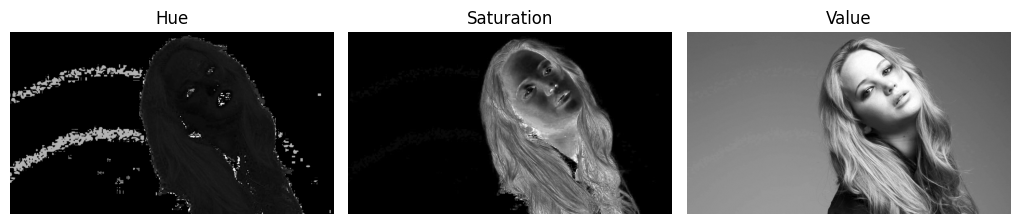

In [15]:
img6 = cv.imread('images/foreground_segmentation.jpeg')
hsv6 = cv.cvtColor(img6, cv.COLOR_BGR2HSV)
H6, S6, V6 = cv.split(hsv6)

planes6 = [(H6, 'Hue'), (S6, 'Saturation'), (V6, 'Value')]
fig, axes = plt.subplots(1, 3, figsize=(10.3, 4.4))
for ax, (im, title) in zip(axes, planes6):
    ax.imshow(im, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

$\textbf{(b) Threshold to extract the foreground mask}$

Neither the saturation plane nor the value plane alone cleanly separates the person from the background (the background has a brightness gradient that overlaps the skin/hair tones), so both are thresholded and combined.

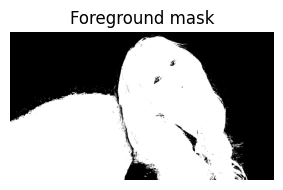

In [16]:
# Otsu on saturation catches hair/clothing, Otsu on value catches
# the bright side of the face
mask_s = cv.threshold(S6, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)[1]
mask_v = cv.threshold(V6, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)[1]
mask = cv.bitwise_or(mask_s, mask_v)

plt.figure(figsize=(3.4, 3.4))
plt.imshow(mask, cmap='gray')
plt.title('Foreground mask')
plt.axis('off')
plt.show()

$\textbf{(c) Extract the foreground and compute its histogram}$

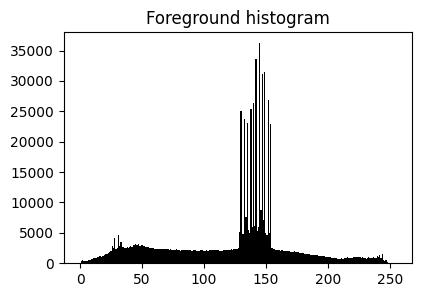

In [17]:
gray6 = cv.cvtColor(img6, cv.COLOR_BGR2GRAY)
foreground = cv.bitwise_and(gray6, gray6, mask=mask)

# Histogram over the foreground pixels only
hist = cv.calcHist([gray6], [0], mask, [256], [0, 256]).flatten()

plt.figure(figsize=(4.5, 3))
plt.bar(np.arange(256), hist, color='k', width=1)
plt.title('Foreground histogram')
plt.show()

$\textbf{(d) Cumulative sum of the foreground histogram}$

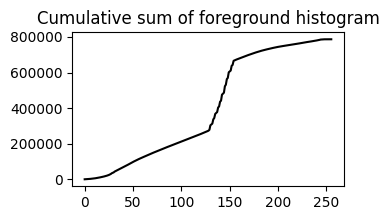

In [18]:
cdf = np.cumsum(hist)

plt.figure(figsize=(3.5, 2))
plt.plot(cdf, color='k')
plt.title('Cumulative sum of foreground histogram')
plt.show()

$\textbf{(e) Histogram-equalize the foreground}$

In [19]:
cdf_min = cdf[cdf > 0].min()
lut = np.clip((cdf - cdf_min) / (cdf[-1] - cdf_min) * 255, 0, 255)
lut = lut.astype(np.uint8)

# Same equalization formula as Q5, on the foreground's own histogram
foreground_eq_full = lut[gray6]
foreground_eq = cv.bitwise_and(
    foreground_eq_full, foreground_eq_full, mask=mask)

$\textbf{(f) Extract the background and add it to the equalized foreground}$

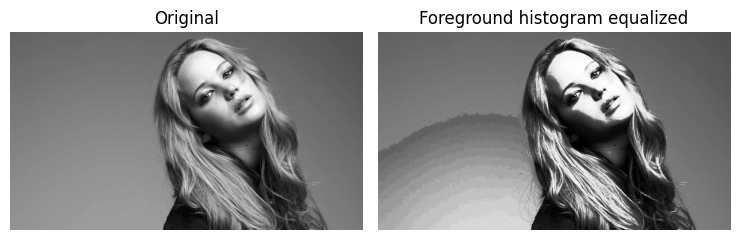

In [20]:
background = cv.bitwise_and(gray6, gray6, mask=cv.bitwise_not(mask))
result6 = cv.add(foreground_eq, background)

imgs6 = [(gray6, 'Original'), (result6, 'Foreground histogram equalized')]
fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.7))
for ax, (im, title) in zip(axes, imgs6):
    ax.imshow(im, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

$\textbf{Discussion:}$ combining Otsu thresholds on saturation and value captures more of the person than either plane alone, but the mask is imperfect around low-contrast hair/background boundaries, visible as residual noise at the foreground edges in the final result. Equalizing only the foreground's own histogram increases contrast within the person without affecting the background, unlike whole-image equalization which would also alter the background's tone.

$\underline{\textbf{Question 7}}$

$\textbf{(a) Sobel filtering using filter2D}$

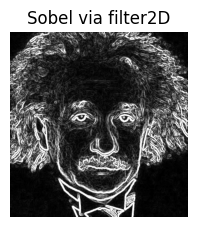

In [21]:
img7 = cv.imread('images/sobel.jpeg', cv.IMREAD_GRAYSCALE)
img7 = img7.astype(np.float64)

Gx = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=np.float64)
Gy = Gx.T

sx_a = cv.filter2D(img7, -1, Gx)
sy_a = cv.filter2D(img7, -1, Gy)
mag_a = np.clip(np.sqrt(sx_a ** 2 + sy_a ** 2), 0, 255).astype(np.uint8)

plt.figure(figsize=(2.4, 2.4))
plt.imshow(mag_a, cmap='gray')
plt.title('Sobel via filter2D')
plt.axis('off')
plt.show()

$\textbf{(b) Writing our own Sobel filtering code}$

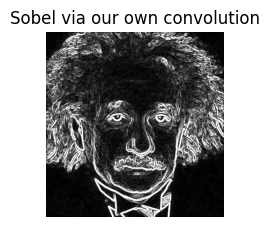

Max difference from filter2D result: 0


In [22]:
def convolve2d(im, kernel):
    # 2D convolution/correlation with reflect padding
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(im, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')
    out = np.zeros_like(im)
    for i in range(kh):
        for j in range(kw):
            patch = padded[i:i + im.shape[0], j:j + im.shape[1]]
            out += kernel[i, j] * patch
    return out

sx_b = convolve2d(img7, Gx)
sy_b = convolve2d(img7, Gy)
mag_b = np.clip(np.sqrt(sx_b ** 2 + sy_b ** 2), 0, 255).astype(np.uint8)

plt.figure(figsize=(2.4, 2.4))
plt.imshow(mag_b, cmap='gray')
plt.title('Sobel via our own convolution')
plt.axis('off')
plt.show()

diff_ab = np.abs(mag_a.astype(int) - mag_b.astype(int)).max()
print('Max difference from filter2D result:', diff_ab)

$\textbf{(c) Sobel filtering using the separable property}$

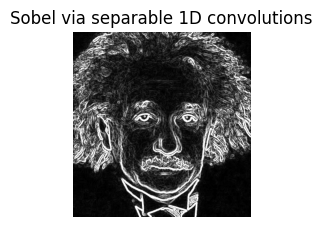

Max difference from part (b) result: 0


In [23]:
def convolve1d(im, kernel_1d, axis):
    # 1D convolution along one axis with reflect padding
    k = len(kernel_1d)
    pad = k // 2
    out = np.zeros_like(im)
    if axis == 0:
        padded = np.pad(im, ((pad, pad), (0, 0)), mode='reflect')
        for i in range(k):
            out += kernel_1d[i] * padded[i:i + im.shape[0], :]
    else:
        padded = np.pad(im, ((0, 0), (pad, pad)), mode='reflect')
        for i in range(k):
            out += kernel_1d[i] * padded[:, i:i + im.shape[1]]
    return out

v = np.array([1, 2, 1], dtype=np.float64)   # smoothing kernel
h = np.array([1, 0, -1], dtype=np.float64)  # differencing kernel

sx_c = convolve1d(convolve1d(img7, v, axis=0), h, axis=1)
sy_c = convolve1d(convolve1d(img7, h, axis=0), v, axis=1)
mag_c = np.clip(np.sqrt(sx_c ** 2 + sy_c ** 2), 0, 255).astype(np.uint8)

plt.figure(figsize=(2.4, 2.4))
plt.imshow(mag_c, cmap='gray')
plt.title('Sobel via separable 1D convolutions')
plt.axis('off')
plt.show()

diff_bc = np.abs(mag_b.astype(int) - mag_c.astype(int)).max()
print('Max difference from part (b) result:', diff_bc)

$\textbf{Discussion:}$ all three implementations, `filter2D`, a manual 2D convolution, and the separable 1D decomposition, produce identical Sobel magnitude images (max pixel difference is 0 in both comparisons). This confirms that the separable-kernel property (Sobel = smoothing kernel outer product with a differencing kernel) is an exact reformulation of the 2D convolution, not an approximation, and it is also the cheaper one to compute since it replaces a $3\times3$ correlation with two 1D passes.

$\underline{\textbf{Question 8}}$

$\textbf{Zoom function supporting nearest-neighbor and bilinear interpolation}$

In [24]:
def zoom_image(img, s, method='bilinear'):
    # Manual pixel-by-pixel zoom
    h, w = img.shape[:2]
    new_h, new_w = max(1, round(h * s)), max(1, round(w * s))
    if img.ndim == 2:
        out_shape = (new_h, new_w)
    else:
        out_shape = (new_h, new_w, img.shape[2])
    out = np.zeros(out_shape, dtype=np.float64)

    for i in range(new_h):
        y = min(max((i + 0.5) / s - 0.5, 0), h - 1)
        for j in range(new_w):
            x = min(max((j + 0.5) / s - 0.5, 0), w - 1)

            if method == 'nearest':
                out[i, j] = img[round(y), round(x)]
            else:
                y0, x0 = int(y), int(x)
                y1, x1 = min(y0 + 1, h - 1), min(x0 + 1, w - 1)
                wy, wx = y - y0, x - x0
                top = img[y0, x0] * (1 - wx) + img[y0, x1] * wx
                bot = img[y1, x0] * (1 - wx) + img[y1, x1] * wx
                out[i, j] = top * (1 - wy) + bot * wy

    return np.clip(out, 0, 255).astype(img.dtype)

$\textbf{Testing: scale the small images up by 4 and compare with the large originals}$

Image 1: NN SSD = 136.27
Image 1: bilinear SSD = 115.13


Image 2: NN SSD = 26.45
Image 2: bilinear SSD = 18.40


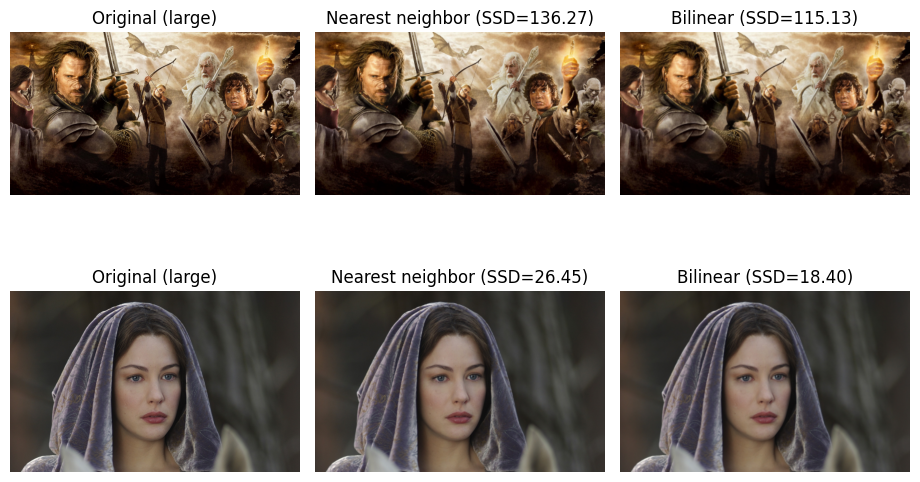

In [25]:
def normalized_ssd(a, b):
    a, b = a.astype(np.float32), b.astype(np.float32)
    return np.sum((a - b) ** 2) / a.size

pairs = [ ('images/zoom_small1.png', 'images/zoom_large1.png'), ('images/zoom_small2.png', 'images/zoom_large2.png'),]
fig, axes = plt.subplots(len(pairs), 3, figsize=(9.3, 3.1 * len(pairs)))

for row, (small_path, large_path) in enumerate(pairs):
    small = cv.imread(small_path)
    large = cv.imread(large_path)
    zoomed_nn = zoom_image(small, 4, method='nearest')
    zoomed_bl = zoom_image(small, 4, method='bilinear')
    ssd_nn = normalized_ssd(zoomed_nn, large)
    ssd_bl = normalized_ssd(zoomed_bl, large)
    row_imgs = [ (large, 'Original (large)'), (zoomed_nn, f'Nearest neighbor (SSD={ssd_nn:.2f})'), (zoomed_bl, f'Bilinear (SSD={ssd_bl:.2f})'),]
    for ax, (im, title) in zip(axes[row], row_imgs):
        ax.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
        ax.set_title(title)
        ax.axis('off')

    print(f'Image {row + 1}: NN SSD = {ssd_nn:.2f}')
    print(f'Image {row + 1}: bilinear SSD = {ssd_bl:.2f}')
plt.tight_layout()
plt.show()

$\textbf{Discussion:}$ bilinear interpolation gives a consistently lower normalized SSD than nearest-neighbor for both test images, since it blends the four nearest pixels instead of picking just one, avoiding the blocky artifacts nearest-neighbor produces. The gap is larger for image 1, which has sharper edges/finer detail than image 2, so the smoothing benefit of bilinear interpolation matters more there.

$\underline{\textbf{Question 9}}$

$\textbf{(a) Segmenting with grabCut}$

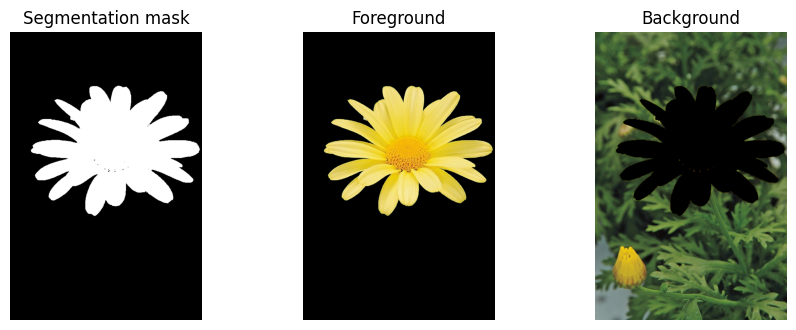

In [26]:
img9 = cv.imread('images/flower_segmentation.jpeg')
h9, w9 = img9.shape[:2]

mask = np.zeros((h9, w9), np.uint8)
bgd_model = np.zeros((1, 65), np.float64)
fgd_model = np.zeros((1, 65), np.float64)

# Rectangle seed covering most of the frame
rect = (int(w9 * 0.05), int(h9 * 0.03), int(w9 * 0.95), int(h9 * 0.75))
cv.grabCut(img9, mask, rect, bgd_model, fgd_model, 5, cv.GC_INIT_WITH_RECT)

fg_mask = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')
foreground = img9 * fg_mask[:, :, None]
background = img9 * (1 - fg_mask[:, :, None])

fig, axes = plt.subplots(1, 3, figsize=(9.3, 3.4))
axes[0].imshow(fg_mask, cmap='gray')
axes[0].set_title('Segmentation mask')
axes[0].axis('off')

axes[1].imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB))
axes[1].set_title('Foreground')
axes[1].axis('off')

axes[2].imshow(cv.cvtColor(background, cv.COLOR_BGR2RGB))
axes[2].set_title('Background')
axes[2].axis('off')
plt.tight_layout()
plt.show()

$\textbf{(b) Blurring the background}$

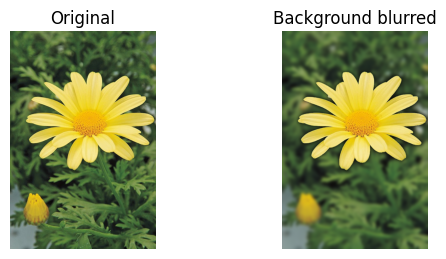

In [27]:
blurred_background = cv.GaussianBlur(background, (35, 35), 0)
enhanced = foreground + blurred_background * (1 - fg_mask[:, :, None])

imgs9 = [(img9, 'Original'), (enhanced, 'Background blurred')]
fig, axes = plt.subplots(1, 2, figsize=(6.5, 2.7))
for ax, (im, title) in zip(axes, imgs9):
    ax.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

$\textbf{(c) Why is the background just beyond the edge of the flower dark?}$

The background image used for blurring has the foreground pixels zeroed out (set to black) before the Gaussian blur is applied. Near the flower's edge, the blur kernel averages in some of those black zeroed-out pixels from just inside the mask boundary, pulling the blurred background values down close to the edge. This creates a dark halo/ring immediately surrounding the flower, even though the true background there was never that dark. It could be avoided by blurring the original image (not the zeroed-out background) and only using the mask to select which blurred pixels to keep.

$\underline{\textbf{Question 10}}$

$\textbf{(a) OpenCV's bilateralFilter vs Gaussian blur}$

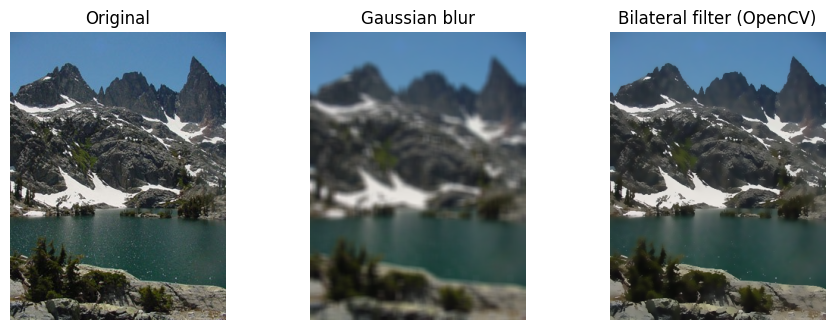

In [28]:
img10 = cv.imread('images/lake_minaret.jpeg')

d, sigma_s, sigma_r = 9, 75, 75
gauss10 = cv.GaussianBlur(img10, (d, d), sigma_s)
bilateral_cv = cv.bilateralFilter(img10, d, sigma_r, sigma_s)

imgs10 = [(img10, 'Original'), (gauss10, 'Gaussian blur'),
          (bilateral_cv, 'Bilateral filter (OpenCV)')]
fig, axes = plt.subplots(1, 3, figsize=(9.3, 3.4))
for ax, (im, title) in zip(axes, imgs10):
    ax.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

$\textbf{(b) My bilateral filter}$

MSE vs OpenCV: 28.909178208679595


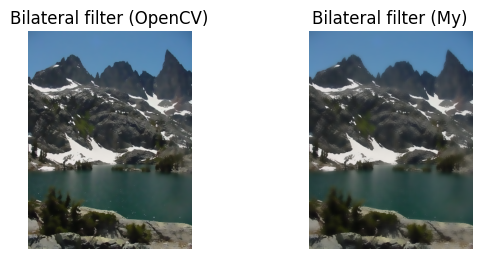

In [29]:
def bilateral_filter(img, d, sigma_s, sigma_r):
    # Manual per-pixel bilateral filter; spatial kernel precomputed once
    img = img.astype(np.float64)
    r = d // 2
    padded = cv.copyMakeBorder(img, r, r, r, r, cv.BORDER_REFLECT)
    h, w = img.shape[:2]
    out = np.zeros_like(img)

    ar = np.arange(-r, r + 1)
    Y, X = np.meshgrid(ar, ar, indexing='ij')
    spatial = np.exp(-(X ** 2 + Y ** 2) / (2 * sigma_s ** 2))

    for i in range(h):
        for j in range(w):
            local = padded[i:i + d, j:j + d]
            diff = local - img[i, j]
            rang = np.exp(-np.sum(diff ** 2, axis=2) / (2 * sigma_r ** 2))
            weight = spatial * rang
            wsum = np.sum(weight)
            weighted = local * weight[:, :, None]
            out[i, j] = np.sum(weighted, axis=(0, 1)) / wsum

    return np.clip(out, 0, 255).astype(np.uint8)

bilateral_own = bilateral_filter(img10, d, sigma_s, sigma_r)
diff = bilateral_own.astype(np.float64) - bilateral_cv.astype(np.float64)
mse = np.mean(diff ** 2)
print('MSE vs OpenCV:', mse)

imgs10b = [(bilateral_cv, 'Bilateral filter (OpenCV)'),
           (bilateral_own, 'Bilateral filter (My)')]
fig, axes = plt.subplots(1, 2, figsize=(6.5, 2.7))
for ax, (im, title) in zip(axes, imgs10b):
    ax.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

$\textbf{Discussion:}$ with matching parameters ($d = 9$, $\sigma_s = \sigma_r = 75$) the manual implementation produces a visually near-identical result to OpenCV's, with an MSE of only a few units, attributable to differences in border handling and floating-point rounding rather than an algorithmic difference. Both filters preserve the sharp shoreline/mountain edges while smoothing the sky and water, unlike the Gaussian blur in part (a), which blurs indiscriminately across those same edges.